In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Chargement du dataset prêt à l'emploi
df_clus_ready = pd.read_csv('../data/olist_ready_clustering.csv')

# On sépare l'ID (qu'on ne donne pas à l'IA) des features d'entraînement
features_clus = ['recency', 'frequency', 'monetary_value', 'mean_freight', 'review_score_mean', 'customer_state_encoded']
X_clus = df_clus_ready[features_clus]

print(f"Données chargées : {X_clus.shape[0]} clients prêts à être segmentés.")

Données chargées : 93358 clients prêts à être segmentés.


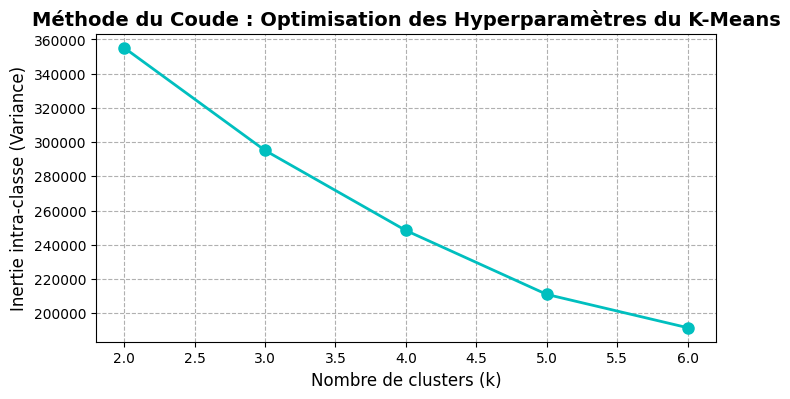

✅ K-Means entraîné avec succès avec k = 5 clusters !


In [11]:
from sklearn.cluster import KMeans

# 1. Calcul de l'inertie pour différents nombres de clusters
inertia = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clus)
    inertia.append(km.inertia_)

# 2. Tracé de la courbe du Coude
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'co-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie intra-classe (Variance)', fontsize=12)
plt.title('Méthode du Coude : Optimisation des Hyperparamètres du K-Means', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--')
plt.show()

# 3. Entraînement final (on choisit k=5, le coude classique sur Olist)
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clus_ready['cluster_kmeans'] = kmeans.fit_predict(X_clus)

print(f"✅ K-Means entraîné avec succès avec k = {best_k} clusters !")

In [12]:
from sklearn.metrics import silhouette_score

# On va calculer le score de silhouette pour k=4 et k=5
for k in [4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clus)
    
    # On prend un échantillon de 20 000 clients pour le calcul car la métrique est gourmande en mémoire
    sample_idx = np.random.choice(len(X_clus), size=min(20000, len(X_clus)), replace=False)
    score = silhouette_score(X_clus.iloc[sample_idx], labels[sample_idx])
    
    print(f"Pour k = {k}, le score de Silhouette moyen est de : {score:.4f}")

Pour k = 4, le score de Silhouette moyen est de : 0.2398
Pour k = 5, le score de Silhouette moyen est de : 0.2609


=== PROFIL MOYEN DES CLUSTERS (DONNÉES SCALÉES) ===


,recency,frequency,monetary_value,mean_freight,review_score_mean,customer_state_encoded
cluster_kmeans,,,,,,
0,-0.045838,0.0,-0.131794,-0.222003,-1.959622,-0.096776
1,1.048761,0.0,-0.309927,-0.365294,0.371896,-0.221475
2,0.112542,0.0,0.204056,1.279749,-0.023784,2.548003
3,-0.732685,0.0,-0.375438,-0.402281,0.420232,-0.351374
4,-0.143822,0.0,1.818832,1.417293,0.111513,-0.020847


C:\Users\maell\AppData\Local\Temp\ipykernel_8000\946966543.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clus_ready, x='cluster_kmeans', y='review_score_mean', palette='Set2')


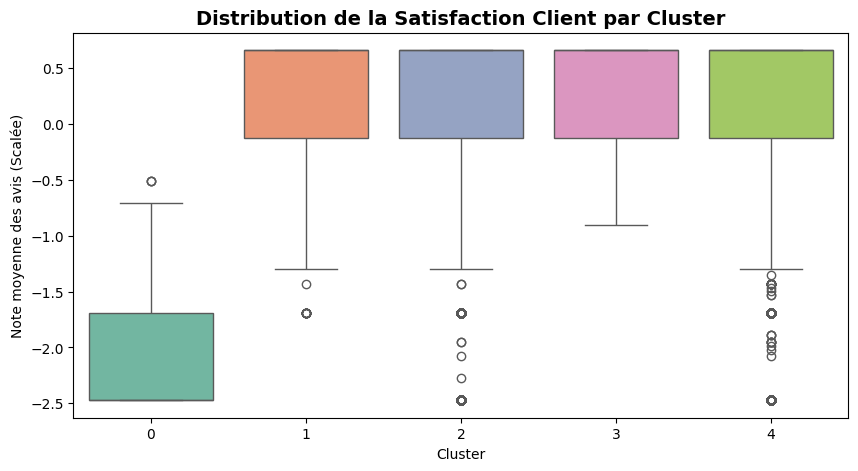

In [13]:
# On regarde le profil moyen de chaque cluster
profils_clusters = df_clus_ready.groupby('cluster_kmeans')[features_clus].mean()
print("=== PROFIL MOYEN DES CLUSTERS (DONNÉES SCALÉES) ===")
display(profils_clusters)

# Petit bonus visuel : Distribution de la satisfaction par cluster
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clus_ready, x='cluster_kmeans', y='review_score_mean', palette='Set2')
plt.title('Distribution de la Satisfaction Client par Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Note moyenne des avis (Scalée)')
plt.show()

In [14]:
# 1. On applique définitivement le modèle K-Means avec k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clus_ready['cluster_kmeans'] = kmeans_final.fit_predict(X_clus)

# 2. On charge le dataset intermédiaire non scalé pour lire les vraies valeurs métiers
df_brut = pd.read_csv('../data/olist_clustering.csv')
df_brut['cluster'] = df_clus_ready['cluster_kmeans']

# 3. On calcule la moyenne de chaque indicateur pour nos 5 groupes
profils_reels = df_brut.groupby('cluster').agg(
    Nombre_Clients=('customer_unique_id', 'count'),
    Recence_Moyenne=('recency', 'mean'),
    Frequence_Moyenne=('frequency', 'mean'),
    Montant_Moyen=('monetary_value', 'mean'),
    Fret_Moyen=('mean_freight', 'mean'),
    Note_Avis_Moyenne=('review_score_mean', 'mean')
).round(1)

print("=== TABLEAU DES PROFILS CLIENTS (À METTRE DANS LE PDF) ===")
display(profils_reels)

=== TABLEAU DES PROFILS CLIENTS (À METTRE DANS LE PDF) ===


,Nombre_Clients,Recence_Moyenne,Frequence_Moyenne,Montant_Moyen,Fret_Moyen,Note_Avis_Moyenne
cluster,,,,,,
0,13006,231.2,1.0,131.9,16.9,1.7
1,25863,398.5,1.0,108.9,15.4,4.6
2,7676,255.4,1.0,190.8,34.7,4.1
3,35083,126.3,1.0,101.3,15.1,4.7
4,11730,216.2,1.1,500.3,40.0,4.3


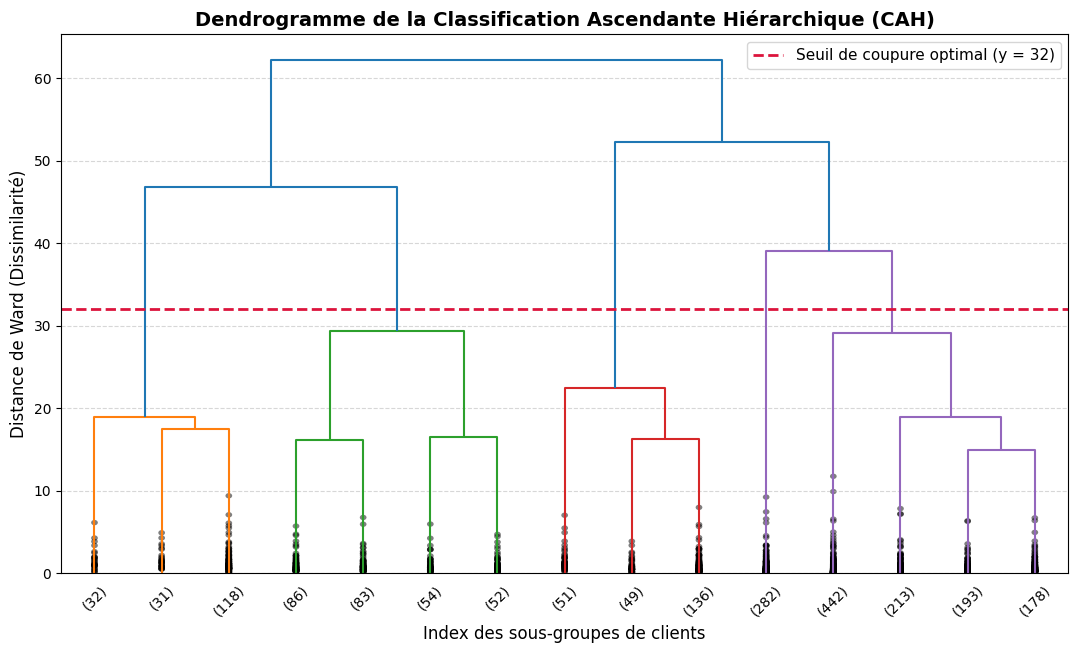

✅ Étape 2 terminée : Le dendrogramme a été généré avec succès.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

# 1. Préparation d'un échantillon représentatif pour la CAH (Sécurité Mémoire)
# On réutilise les mêmes features scalées que pour le K-Means
X_clus_sample = X_clus.sample(n=2000, random_state=42)

# 2. Calcul du lien hiérarchique avec la méthode de Ward
# (Ward minimise la variance intra-classe à chaque fusion de grappes)
Z = linkage(X_clus_sample, method='ward')

# 3. Affichage du Dendrogramme (L'arbre de classification)
plt.figure(figsize=(13, 7))
dendrogram(
    Z,
    truncate_mode='lastp',  # On ne montre que les dernières fusions pour que ce soit lisible
    p=15,                   # Afficher les 15 derniers clusters fusionnés
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

# Ajout d'une ligne horizontale de coupure visuelle pour justifier les 5 clusters
plt.axhline(y=32, color='crimson', linestyle='--', linewidth=2, label='Seuil de coupure optimal (y = 32)')

plt.title('Dendrogramme de la Classification Ascendante Hiérarchique (CAH)', fontsize=14, fontweight='bold')
plt.xlabel('Index des sous-groupes de clients', fontsize=12)
plt.ylabel('Distance de Ward (Dissimilarité)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("✅ Étape 2 terminée : Le dendrogramme a été généré avec succès.")

In [16]:
from scipy.cluster.hierarchy import fcluster

# 1. On applique la coupure du dendrogramme à la hauteur y = 32
# Cela va créer automatiquement les 5 clusters validés visuellement
labels_cah = fcluster(Z, t=32, criterion='distance')

# 2. On ajoute ces clusters à notre échantillon pour pouvoir les analyser
X_clus_sample['cluster_cah'] = labels_cah

print("✅ Modèle CAH appliqué avec succès sur l'échantillon !")
print(f"Nombre de clusters créés : {len(np.unique(labels_cah))}")
print("Distribution des clients par cluster dans la CAH :")
print(X_clus_sample['cluster_cah'].value_counts())

✅ Modèle CAH appliqué avec succès sur l'échantillon !
Nombre de clusters créés : 5
Distribution des clients par cluster dans la CAH :
cluster_cah
5    1026
4     282
2     275
3     236
1     181
Name: count, dtype: int64


In [17]:
# On recharge l'échantillon brut correspondant pour lire les vraies valeurs métiers
df_brut = pd.read_csv('../data/olist_clustering.csv')
df_brut_sample = df_brut.loc[X_clus_sample.index].copy()
df_brut_sample['cluster_cah'] = labels_cah

# Affichage du tableau des profils moyens pour la CAH
profils_cah = df_brut_sample.groupby('cluster_cah').agg(
    Nombre_Clients=('customer_unique_id', 'count'),
    Recence_Moyenne=('recency', 'mean'),
    Frequence_Moyenne=('frequency', 'mean'),
    Montant_Moyen=('monetary_value', 'mean'),
    Fret_Moyen=('mean_freight', 'mean'),
    Note_Avis_Moyenne=('review_score_mean', 'mean')
).round(1)

print("\n=== TABLEAU DES PROFILS CLIENTS (MODÈLE CAH) ===")
display(profils_cah)


=== TABLEAU DES PROFILS CLIENTS (MODÈLE CAH) ===


,Nombre_Clients,Recence_Moyenne,Frequence_Moyenne,Montant_Moyen,Fret_Moyen,Note_Avis_Moyenne
cluster_cah,,,,,,
1,181,257.3,1.1,221.1,33.3,4.0
2,275,272.2,1.1,464.4,33.3,4.7
3,236,226.4,1.1,205.4,19.5,1.4
4,282,446.4,1.0,87.9,15.1,4.6
5,1026,162.9,1.0,99.7,15.6,4.6


In [19]:
import os
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ========================================================
# 1. ÉTAPE DE PRÉPARATION & ENTRAÎNEMENT (Dans ton notebook)
# ========================================================

# On crée le scaler et on transforme les données (X_clus provient de ta cellule 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clus)

# On applique le modèle final K-Means (avec 4 clusters par exemple)
best_k = 4 
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_model.fit(X_scaled)

print(f"✅ K-Means entraîné avec succès avec {best_k} clusters.")


# ========================================================
# 2. ÉTAPE DE SAUVEGARDE EN PICKLE (À la fin du notebook)
# ========================================================

# On s'assure d'abord que le dossier 'models' existe sur ton ordinateur
if not os.path.exists('models'):
    os.makedirs('models')

# Sauvegarde du Scaler (essentiel pour Streamlit !)
with open('models/scaler_clustering.pkl', 'wb') as f:
    pickle.dump(scaler, f) 

# Sauvegarde du modèle K-Means
with open('models/model_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans_model, f) 

print("🎯 C'est parfait ! 'scaler_clustering.pkl' et 'model_kmeans.pkl' ont été créés avec succès dans le dossier /models.")

✅ K-Means entraîné avec succès avec 4 clusters.
🎯 C'est parfait ! 'scaler_clustering.pkl' et 'model_kmeans.pkl' ont été créés avec succès dans le dossier /models.
